In [1]:
%cd ..

/home/fzimin/Projects/depth-poset


In [128]:
import numpy as np
import networkx as nx
import pandas as pd


import matplotlib.pyplot as plt

from src.depth import DepthPoset, ShallowPair
from src.transpositions import Transposition

NameError: name 'ShallowPair' is not defined

# Data

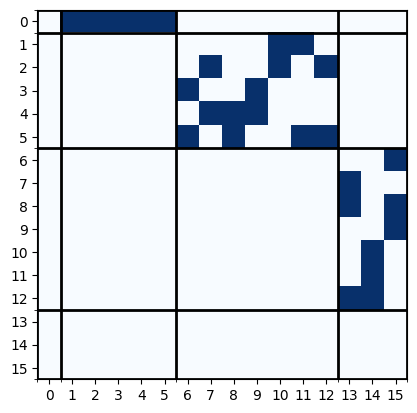

In [4]:
delta_matrix = np.zeros([16, 16], dtype=int)
delta_matrix[0, 1:6] = 1
delta_matrix[1:6, 6:13] = np.array([[1, 1, 0, 0, 0, 0, 0], 
                                    [1, 0, 1, 1, 0, 0, 0], 
                                    [0, 1, 1, 0, 1, 1, 0], 
                                    [0, 0, 0, 1, 1, 0, 1], 
                                    [0, 0, 0, 0, 0, 1, 1]])
delta_matrix[6:13, 13:16] = np.array([[1, 0, 0], 
                                      [1, 0, 0], 
                                      [1, 1, 0], 
                                      [0, 1, 0], 
                                      [0, 1, 1], 
                                      [0, 0, 1], 
                                      [0, 0, 1]])
reorder = np.array([ 0,  1,  2,  5,  4,  3, 11,  9, 10, 12,  6,  7,  8, 14, 13, 15])


delta_matrix = delta_matrix[reorder, :][:, reorder]


fig, ax = plt.subplots()

ax.imshow(delta_matrix, cmap='Blues')
ax.set_xticks(np.arange(len(delta_matrix)))
ax.set_xticklabels(np.arange(len(delta_matrix)))
ax.set_xticks([-0.5, 0.5, 5.5, 12.5, 15.5], minor=True)

ax.set_yticks(np.arange(len(delta_matrix)))
ax.set_yticklabels(np.arange(len(delta_matrix)))
ax.set_yticks([-0.5, 0.5, 5.5, 12.5, 15.5], minor=True)

ax.grid(which="minor", linewidth=2, alpha=1.0, color='black')

plt.show()

In [5]:
delta_order = np.arange(16)
delta_order

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [6]:
delta_dims = -np.ones(len(delta_matrix), dtype=int)
delta_dims[1:6] = 0
delta_dims[6:13] = 1
delta_dims[13:16] = 2

delta_dims

array([-1,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2])

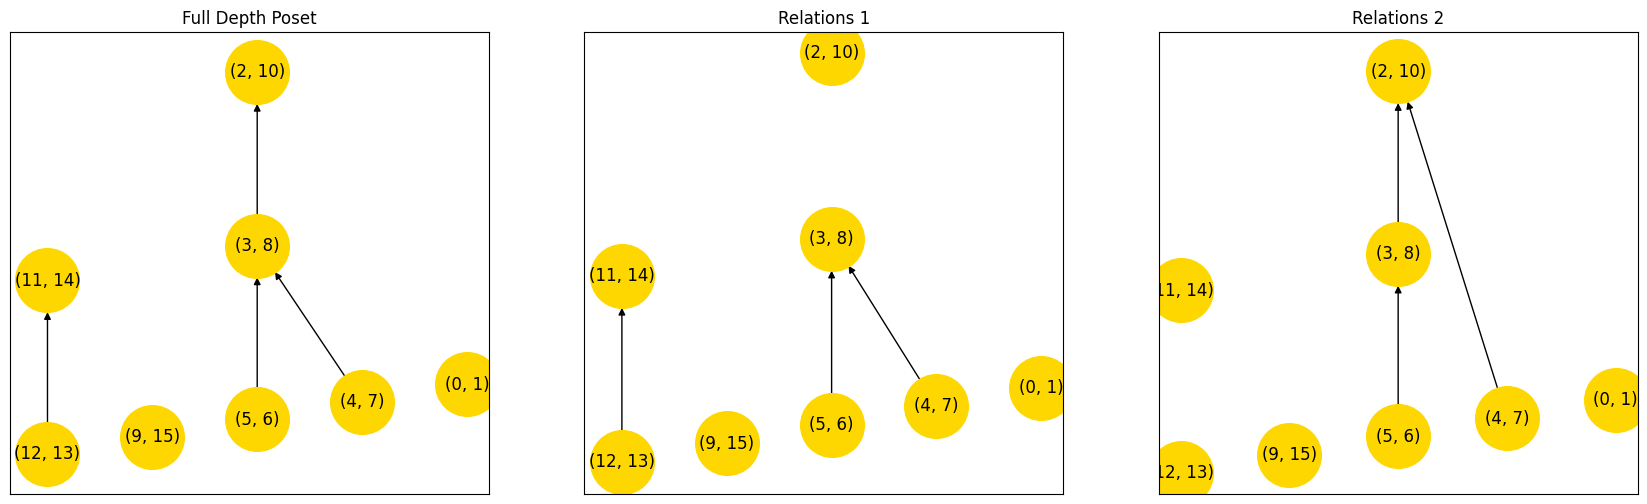

In [90]:
dp_bt = DepthPoset.from_border_matrix(delta_matrix, delta_dims)

pos = dp_bt.hasse_layout(alignment_slope=0.1)
labels = {node: (node.birth_index, node.death_index) for node in dp_bt.nodes}


fig, axs = plt.subplots(1, 3, figsize=(21, 6))

axs[0].set_title('Full Depth Poset')
axs[1].set_title('Relations 1')
axs[2].set_title('Relations 2')
nx.draw_networkx(dp_bt.get_transitive_reduction(), ax=axs[0], pos=pos, labels=labels, node_size=2100, node_color='gold')
nx.draw_networkx(dp_bt.get_column_bottom_to_top_reduction().get_transitive_reduction(), ax=axs[1], pos=pos, labels=labels, node_size=2100, node_color='gold')
nx.draw_networkx(dp_bt.get_row_left_to_right_reduction().get_transitive_reduction(), ax=axs[2], pos=pos, labels=labels, node_size=2100, node_color='gold')

plt.show()

# Collect Transpositions

In [135]:
df_transps = pd.DataFrame({'cell0': np.arange(0, 15), 'cell1': np.arange(1, 16)})

df_transps['transposition'] = df_transps.apply(lambda row: Transposition(delta_matrix, row['cell0'], row['cell1'], 
                                                                         order=delta_order, dims=delta_dims), axis=1)
df_transps['dim'] = df_transps['transposition'].apply(lambda transp: transp.dim)
df_transps['transposition_type'] = df_transps['transposition'].apply(lambda transp: transp.get_transposition_type())
df_transps['switch_type'] = df_transps['transposition'].apply(lambda transp: transp.get_switch_type())
df_transps['xyab'] = df_transps['transposition'].apply(lambda transp: transp.get_xyab())

for i, c in enumerate('xyab'):
    df_transps[c] = df_transps['xyab'].apply(lambda arr: arr[i])
df_transps = df_transps.drop(columns='xyab')


df_transps['dp_at'] = df_transps['transposition'].apply(lambda trandp: transp.next_depth_poset())
df_transps

/home/fzimin/Projects/depth-poset/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:201: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)


,cell0,cell1,transposition,dim,transposition_type,switch_type,x,y,a,b,dp_at
0,0,1,"<0, 1>",NaN,birth-death,no switch,1,0,1,0,<src.depth.DepthPoset object at 0x78bbce6053a0>
1,1,2,"<1, 2>",0.0,birth-death,switch forward,2,10,0,1,<src.depth.DepthPoset object at 0x78bbce5ad0d0>
2,2,3,"<2, 3>",0.0,birth-birth,switch forward,3,8,2,10,<src.depth.DepthPoset object at 0x78bbce5afe30>
3,3,4,"<3, 4>",0.0,birth-birth,no switch,4,7,3,8,<src.depth.DepthPoset object at 0x78bbce2199a0>
4,4,5,"<4, 5>",0.0,birth-birth,no switch,5,6,4,7,<src.depth.DepthPoset object at 0x78bbce5ae990>
5,5,6,"<5, 6>",NaN,birth-death,no switch,6,5,6,5,<src.depth.DepthPoset object at 0x78bbce5ad490>
6,6,7,"<6, 7>",1.0,death-death,no switch,4,7,5,6,<src.depth.DepthPoset object at 0x78bbce067b30>
7,7,8,"<7, 8>",1.0,death-death,switch forward,3,8,4,7,<src.depth.DepthPoset object at 0x78bbce5ada30>
8,8,9,"<8, 9>",1.0,birth-death,switch forward,9,15,3,8,<src.depth.DepthPoset object at 0x78bbce5afc80>
9,9,10,"<9, 10>",1.0,birth-death,no switch,10,2,15,9,<src.depth.DepthPoset object at 0x78bbce065fa0>


In [110]:
df_transps[['transposition_type', 'switch_type']].value_counts().sort_index()

transposition_type  switch_type   
birth-birth         no switch         3
                    switch forward    1
birth-death         no switch         4
                    switch forward    3
death-death         no switch         2
                    switch forward    2
Name: count, dtype: int64

In [134]:
transp.dim

np.int64(0)

## Birth-Birth Transposition

__Lemma 3.3__: Let $f: K\to\mathbb{R}$ be a filter on a Lefscetz complex and $(x, y)$, $(a, b)$ birth-death pairs of matching dimension such that $f(a) < f(x) < f(y) < f(b)$ and $a, x$ are consequtive in the ordering implyed by the filer. Then $a<y$ iff the transposition of $x, a$ is a BB-type switch transposition, and the succesors predecessors determined by Algorithm 1 satisfy:

8. $\text{Succ}_1^\text{at}(a, y) = \text{Succ}_1^\text{bt}(x, y) \oplus \{(x, b)\} \oplus \text{Succ}_1^\text{bt}(a, b)$
9. $\text{Succ}_1^\text{at}(x, b) = \text{Succ}_1^\text{bt}(a, b)$
10. $\text{Pred}_1^\text{at}(a, y) = \text{Pred}_1^\text{bt}(x, y)$
11. $\text{Pred}_1^\text{at}(x, b) = \text{Pred}_1^\text{bt}(a, b) \oplus \{(a, y)\}$

Writing $L$ and $M$ for the birth-death pairs $(s, t)$ that satisfy $f(t) < f(y)$ and $f(y) < f(t) < f(b)$, respectively, the succesors and predecessors determined by algorithm 2 satisfy
$$
    L(x, y, a, b) = \{(s, t)\in \text{DP}: \; f(t) < f(y)\}
$$
$$
    M(x, y, a, b) = \{(s, t)\in \text{DP}: \; f(y) < f(t) < f(b)\}
$$


12. $\text{Succ}_2^\text{at}(a, y) = \text{Succ}_2^\text{bt}(x, y) \oplus \{(x, b), (a, b)\}$ 
13. $\text{Succ}_2^\text{at}(x, b) = \text{Succ}_2^\text{bt}(a, b)$
14. $\text{Pred}_2^\text{at}(a, y) = \left[\text{Pred}_2^\text{bt}(a, b) \cap L\right]$
15. $\text{Pred}_2^\text{at}(x, b) = \text{Pred}_2^\text{bt}(x, y) \oplus \{(a, y)\} \oplus \left[\text{Pred}_2^\text{at}(a, b)\cap M\right]$

Otherwise the relations determined by both algorithms remain as is except if $x<b$, in which case

16. $\text{Succ}_1^\text{at}(x, y) = \text{Succ}_1^\text{bt}(x, y) \oplus \{(a, b)\} \oplus \text{Succ}_1^\text{bt}(a, b)$
17. $\text{Pred}_1^\text{at}(a, b) = \text{Pred}_1^\text{bt}(a, b) \oplus \{(x, y)\}$

In [204]:
def get_succ1(dp: DepthPoset, x, y):
    return set(dp.get_column_bottom_to_top_reduction().get_succesors((x, y)).nodes)

def get_pred1(dp: DepthPoset, x, y):
    return set(dp.get_column_bottom_to_top_reduction().get_predecessors((x, y)).nodes)

def get_succ2(dp: DepthPoset, x, y):
    return set(dp.get_row_left_to_right_reduction().get_succesors((x, y)).nodes)

def get_pred2(dp: DepthPoset, x, y):
    return set(dp.get_row_left_to_right_reduction().get_predecessors((x, y)).nodes)


In [205]:
get_succ1(dp_bt, 3, 8) == {ShallowPair(2, 10, 2, 10, 0)}

True

In [206]:
from functools import wraps


def resolve_eq_params(func):
    @wraps(func)
    def wrapper(transposition: Transposition,dp_bt: DepthPoset, dp_at: DepthPoset | None = None, dim: int | None = None,
                x: int | None = None, y: int | None = None, a: int | None = None, b: int | None = None, **kwargs,):
        if dim is None:
            dim = transposition.dim

        if dp_at is None:
            dp_at = transposition.next_depth_poset()

        if any(v is None for v in (x, y, a, b)):
            x, y, a, b = transposition.get_xyab()

        return func(dp_bt=dp_bt, dp_at=dp_at, dim=dim, x=x, y=y, a=a, b=b)

    return wrapper

In [207]:
def oplus(*args):
    res = set()
    for arg in args:
        res = res.symmetric_difference(arg)
    return res

In [208]:
#8. $\text{Succ}_1^\text{at}(a, y) = \text{Succ}_1^\text{bt}(x, y) \oplus \{(x, b)\} \oplus \text{Succ}_1^\text{bt}(a, b)$
#9. $\text{Succ}_1^\text{at}(x, b) = \text{Succ}_1^\text{bt}(a, b)$
#10. $\text{Pred}_1^\text{at}(a, y) = \text{Pred}_1^\text{bt}(x, y)$
#11. $\text{Pred}_1^\text{at}(x, b) = \text{Pred}_1^\text{bt}(a, b) \oplus \{(a, y)\}$

@resolve_eq_params
def eq8(dp_bt: DepthPoset, dp_at: DepthPoset, dim: int, x: int, y: int, a: int, b: int):
    r"""
    $\text{Succ}_1^\text{at}(a, y) = \text{Succ}_1^\text{bt}(x, y) \oplus \{(x, b)\} \oplus \text{Succ}_1^\text{bt}(a, b)$
    """
    succ1_at_ay = get_succ1(dp_at, a, y)
    succ1_bt_xy = get_succ1(dp_bt, x, y)
    succ1_bt_ab = get_succ1(dp_bt, a, b)

    return succ1_at_ay == oplus(succ1_bt_xy, succ1_bt_ab, {ShallowPair(x, b, x, b, dim)})

@resolve_eq_params
def eq9(dp_bt: DepthPoset, dp_at: DepthPoset, dim: int, x: int, y: int, a: int, b: int):
    r"""
    $\text{Succ}_1^\text{at}(x, b) = \text{Succ}_1^\text{bt}(a, b)$
    """
    succ1_at_xb = get_succ1(dp_at, x, b)
    succ1_bt_ab = get_succ1(dp_bt, a, b)
    return succ1_at_xb == succ1_bt_ab


@resolve_eq_params
def eq10(dp_bt: DepthPoset, dp_at: DepthPoset, dim: int, x: int, y: int, a: int, b: int):
    r"""
    $\text{Pred}_1^\text{at}(a, y) = \text{Pred}_1^\text{bt}(x, y)$
    """
    pred1_at_ay = get_pred1(dp_at, a, y)
    pred1_bt_xy = get_pred1(dp_bt, x, y)
    return pred1_at_ay == pred1_bt_xy


@resolve_eq_params
def eq11(dp_bt: DepthPoset, dp_at: DepthPoset, dim: int, x: int, y: int, a: int, b: int):
    r"""
    $\text{Pred}_1^\text{at}(x, b) = \text{Pred}_1^\text{bt}(a, b) \oplus \{(a, y)\}$
    """
    pred1_at_xb = get_pred1(dp_at, x, b)
    pred1_bt_ab = get_pred1(dp_at, x, b)
    return pred1_at_xb == oplus(pred1_bt_ab, {ShallowPair(a, y, a, y, dim)})
            

In [219]:
def get_l_set(dp: DepthPoset, x=None, y=None, a=None, b=None):
    r"""
    $L(x, y, a, b) = \{(s, t)\in \text{DP}: \; f(t) < f(y)\}$
    """
    return {node for node in dp.nodes if node.death_index < y}

def get_m_set(dp: DepthPoset, x=None, y=None, a=None, b=None):
    r"""
    $M(x, y, a, b) = \{(s, t)\in \text{DP}: \; f(y) < f(t) < f(b)\}$
    """
    return {node for node in dp.nodes if (y < node.death_index) and (node.death_index < b)}

In [220]:
#12. $\text{Succ}_2^\text{at}(a, y) = \text{Succ}_2^\text{bt}(x, y) \oplus \{(x, b), (a, b)\}$ 
#13. $\text{Succ}_2^\text{at}(x, b) = \text{Succ}_2^\text{bt}(a, b)$
#14. $\text{Pred}_2^\text{at}(a, y) = \left[\text{Pred}_2^\text{bt}(a, b) \cap L\right]$
#15. $\text{Pred}_2^\text{at}(x, b) = \text{Pred}_2^\text{bt}(x, y) \oplus \{(a, y)\} \oplus \left[\text{Pred}_2^\text{at}(a, b)\cap M\right]$

@resolve_eq_params
def eq12(dp_bt: DepthPoset, dp_at: DepthPoset, dim: int, x: int, y: int, a: int, b: int):
    r"""
    $\text{Succ}_2^\text{at}(a, y) = \text{Succ}_2^\text{bt}(x, y) \oplus \{(x, b), (a, b)\}$ 
    """
    succ2_at_ay = get_succ2(dp_at, a, y)
    succ2_bt_xy = get_succ2(dp_bt, x, y)

    return succ2_at_ay == oplus(succ2_bt_xy, {ShallowPair(x, b, x, b, dim), ShallowPair(a, b, a, b, dim)})

@resolve_eq_params
def eq13(dp_bt: DepthPoset, dp_at: DepthPoset, dim: int, x: int, y: int, a: int, b: int):
    r"""
    $\text{Succ}_2^\text{at}(x, b) = \text{Succ}_2^\text{bt}(a, b)$
    """
    succ2_at_xb = get_succ2(dp_at, x, b)
    succ2_bt_ab = get_succ2(dp_bt, a, b)

    return succ2_at_xb == succ2_bt_ab

@resolve_eq_params
def eq14(dp_bt: DepthPoset, dp_at: DepthPoset, dim: int, x: int, y: int, a: int, b: int):
    r"""
    $\text{Pred}_2^\text{at}(a, y) = \left[\text{Pred}_2^\text{bt}(a, b) \cap L\right]$
    """
    pred2_at_ay = get_pred2(dp_at, a, y)
    pred2_bt_ab = get_pred2(dp_bt, a, b)
    l_set = get_l_set(dp_bt, x, y, a, b)

    return pred2_at_ay == (pred2_bt_ab & l_set)

@resolve_eq_params
def eq15(dp_bt: DepthPoset, dp_at: DepthPoset, dim: int, x: int, y: int, a: int, b: int):
    r"""
    $\text{Pred}_2^\text{at}(x, b) = \text{Pred}_2^\text{bt}(x, y) \oplus \{(a, y)\} \oplus \left[\text{Pred}_2^\text{at}(a, b)\cap M\right]$
    """
    pred2_at_xb = get_pred2(dp_at, x, b)
    pred2_bt_xy = get_pred2(dp_bt, x, y)
    pred2_bt_ab = get_pred2(dp_bt, a, b)
    m_set = get_m_set(dp_bt, x, y, a, b)

    return pred2_at_xb == oplus(pred2_bt_xy, {ShallowPair(a, y, a, y, dim)}, pred2_bt_ab & m_set)





In [221]:
{1, 2, 3} & {2, 4, 3}

{2, 3}

In [222]:
bb_switch_forward_eq_funs = [eq8, eq9, eq10, eq11, eq12, eq13, eq14, eq15]

In [223]:
df_transps_bb = df_transps[df_transps['transposition_type'] == 'birth-birth'].copy()
df_transps_bb['dp_bt'] = dp_bt

for eq_fun in bb_switch_forward_eq_funs:
    df_transps_bb[eq_fun.__name__] = df_transps_bb.apply(lambda row: eq_fun(**row) if (row['transposition_type'] == 'birth-birth') and (row['switch_type'] == 'switch forward') else None, axis=1)
df_transps_bb

,cell0,cell1,transposition,dim,transposition_type,switch_type,x,y,a,b,dp_at,dp_bt,eq8,eq9,eq10,eq11,eq12,eq13,eq14,eq15
2,2,3,"<2, 3>",0.0,birth-birth,switch forward,3,8,2,10,<src.depth.DepthPoset object at 0x78bbce5afe30>,<src.depth.DepthPoset object at 0x78bbce1ae4e0>,False,True,False,False,False,True,False,False
3,3,4,"<3, 4>",0.0,birth-birth,no switch,4,7,3,8,<src.depth.DepthPoset object at 0x78bbce2199a0>,<src.depth.DepthPoset object at 0x78bbce1ae4e0>,None,None,None,None,None,None,None,None
4,4,5,"<4, 5>",0.0,birth-birth,no switch,5,6,4,7,<src.depth.DepthPoset object at 0x78bbce5ae990>,<src.depth.DepthPoset object at 0x78bbce1ae4e0>,None,None,None,None,None,None,None,None
11,11,12,"<11, 12>",1.0,birth-birth,no switch,12,13,11,14,<src.depth.DepthPoset object at 0x78bbce5aff50>,<src.depth.DepthPoset object at 0x78bbce1ae4e0>,None,None,None,None,None,None,None,None
